In [1]:
import pandas as pd
import numpy as np
import requests
import joblib
import os
from datetime import datetime, timezone, timedelta
from pymongo import MongoClient
from dotenv import load_dotenv
import warnings
warnings.filterwarnings("ignore")

load_dotenv("../.env")

API_KEY     = os.getenv("OPENWEATHER_API_KEY")
LAT         = os.getenv("LAT")
LON         = os.getenv("LON")
CITY        = os.getenv("CITY")
MONGODB_URI = os.getenv("MONGODB_URI")

print("Imports done ✅")

Imports done ✅


In [2]:
ridge  = joblib.load("../models/ridge.pkl")
scaler = joblib.load("../models/scaler.pkl")
le     = joblib.load("../models/label_encoder.pkl")

feature_cols = [
    "hour", "day", "month",
    "temperature", "humidity", "wind_speed",
    "pm2_5", "pm10", "no2", "co", "o3",
    "aqi_lag_1", "aqi_lag_3", "aqi_lag_24",
    "aqi_rolling_mean_24", "aqi_change_rate",
    "time_of_day", "is_weekend", "season"
]

print("Models loaded ✅")

Models loaded ✅


In [3]:
def get_time_of_day(hour):
    if 5 <= hour < 12:    return "morning"
    elif 12 <= hour < 17: return "afternoon"
    elif 17 <= hour < 21: return "evening"
    else:                 return "night"

def get_season(month):
    if month in [12, 1, 2]:  return "winter"
    elif month in [3, 4, 5]: return "spring"
    elif month in [6, 7, 8]: return "summer"
    else:                    return "autumn"

def aqi_label(aqi):
    if aqi <= 20:   return "Good"
    elif aqi <= 40: return "Fair"
    elif aqi <= 60: return "Moderate"
    elif aqi <= 80: return "Poor"
    elif aqi <= 100: return "Very Poor"
    else:           return "Extremely Poor"

def aqi_color(cat):
    return {
        "Good":           "#22c55e",
        "Fair":           "#3b82f6",
        "Moderate":       "#f59e0b",
        "Poor":           "#ef4444",
        "Very Poor":      "#7f1d1d",
        "Extremely Poor": "#450a0a"
    }.get(cat, "#6b7280")

print("Helpers defined ✅")

Helpers defined ✅


In [4]:
def fetch_current_pollution():
    url  = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={LAT}&lon={LON}&appid={API_KEY}"
    data = requests.get(url).json()
    components = data["list"][0]["components"]
    return {
        "pm2_5": components["pm2_5"],
        "pm10":  components["pm10"],
        "no2":   components["no2"],
        "co":    components["co"],
        "o3":    components["o3"],
    }

current_pollution = fetch_current_pollution()
print("Current pollution:")
for k, v in current_pollution.items():
    print(f"  {k}: {v}")

Current pollution:
  pm2_5: 32.25
  pm10: 128.83
  no2: 0.4
  co: 99.86
  o3: 97.8


In [5]:
def fetch_weather_forecast():
    url  = f"https://api.openweathermap.org/data/2.5/forecast?lat={LAT}&lon={LON}&appid={API_KEY}&units=metric"
    data = requests.get(url).json()

    records = []
    for item in data["list"]:
        dt = datetime.fromtimestamp(item["dt"], tz=timezone.utc)
        records.append({
            "timestamp":   dt,
            "temperature": item["main"]["temp"],
            "humidity":    item["main"]["humidity"],
            "wind_speed":  item["wind"]["speed"]
        })

    df = pd.DataFrame(records)
    print(f"Fetched {len(df)} forecast records")
    print(f"From: {df['timestamp'].min()}")
    print(f"To:   {df['timestamp'].max()}")
    return df

weather_forecast = fetch_weather_forecast()

Fetched 40 forecast records
From: 2026-05-24 12:00:00+00:00
To:   2026-05-29 09:00:00+00:00


In [6]:
client      = MongoClient(MONGODB_URI)
db          = client["pearls_aqi"]
data        = list(db["aqi_engineered"].find(
    {}, {"_id": 0, "timestamp": 1, "aqi": 1}
))
client.close()

hist_df     = pd.DataFrame(data).sort_values("timestamp").reset_index(drop=True)
aqi_history = hist_df["aqi"].tolist()

print(f"Loaded {len(aqi_history)} historical AQI values")
print(f"Last AQI: {aqi_history[-1]}")
print(f"Last 3:   {aqi_history[-3:]}")

Loaded 2160 historical AQI values
Last AQI: 105
Last 3:   [104, 105, 105]


In [7]:
now              = datetime.now(timezone.utc)
aqi_history_copy = aqi_history.copy()
hourly_forecasts = []

# encode categories
season_map   = {"winter": 0, "spring": 1, "summer": 2, "autumn": 3}
tod_classes  = list(le.classes_)

for _, row in weather_forecast.iterrows():
    dt = row["timestamp"]

    if dt <= now: continue
    if dt > now + timedelta(hours=72): break

    # lag features
    aqi_lag_1           = float(aqi_history_copy[-1])
    aqi_lag_3           = float(aqi_history_copy[-3])  if len(aqi_history_copy) >= 3  else aqi_lag_1
    aqi_lag_24          = float(aqi_history_copy[-24]) if len(aqi_history_copy) >= 24 else aqi_lag_1
    aqi_rolling_mean_24 = float(np.mean(aqi_history_copy[-24:]))
    aqi_change_rate     = float(aqi_history_copy[-1] - aqi_history_copy[-2]) if len(aqi_history_copy) >= 2 else 0.0

    # time features
    tod     = get_time_of_day(dt.hour)
    tod_enc = tod_classes.index(tod) if tod in tod_classes else 0
    season  = get_season(dt.month)
    sea_enc = season_map.get(season, 0)

    features = pd.DataFrame([{
        "hour":                 dt.hour,
        "day":                  dt.day,
        "month":                dt.month,
        "temperature":          row["temperature"],
        "humidity":             row["humidity"],
        "wind_speed":           row["wind_speed"],
        "pm2_5":                current_pollution["pm2_5"],
        "pm10":                 current_pollution["pm10"],
        "no2":                  current_pollution["no2"],
        "co":                   current_pollution["co"],
        "o3":                   current_pollution["o3"],
        "aqi_lag_1":            aqi_lag_1,
        "aqi_lag_3":            aqi_lag_3,
        "aqi_lag_24":           aqi_lag_24,
        "aqi_rolling_mean_24":  aqi_rolling_mean_24,
        "aqi_change_rate":      aqi_change_rate,
        "time_of_day":          tod_enc,
        "is_weekend":           1 if dt.weekday() in [5, 6] else 0,
        "season":               sea_enc
    }])

    scaled    = scaler.transform(features[feature_cols])
    pred_aqi  = float(ridge.predict(scaled)[0])
    pred_aqi  = max(0, pred_aqi)

    hourly_forecasts.append({
        "timestamp":     dt,
        "date":          dt.strftime("%Y-%m-%d"),
        "hour":          dt.hour,
        "predicted_aqi": round(pred_aqi, 1),
        "temperature":   row["temperature"],
        "humidity":      row["humidity"],
        "wind_speed":    row["wind_speed"]
    })

    aqi_history_copy.append(pred_aqi)

df_forecast = pd.DataFrame(hourly_forecasts)
print(f"Total hourly predictions: {len(df_forecast)}")
df_forecast.head()

Total hourly predictions: 24


,timestamp,date,hour,predicted_aqi,temperature,humidity,wind_speed
0,2026-05-24 12:00:00+00:00,2026-05-24,12,105.0,48.82,5,5.91
1,2026-05-24 15:00:00+00:00,2026-05-24,15,105.1,45.42,7,4.93
2,2026-05-24 18:00:00+00:00,2026-05-24,18,105.2,40.21,13,4.24
3,2026-05-24 21:00:00+00:00,2026-05-24,21,105.3,37.28,12,3.46
4,2026-05-25 00:00:00+00:00,2026-05-25,0,105.4,34.83,8,2.82


In [8]:
daily = df_forecast.groupby("date").agg(
    predicted_aqi=("predicted_aqi", "mean"),
    temperature=("temperature",   "mean"),
    humidity=("humidity",         "mean"),
    wind_speed=("wind_speed",     "mean")
).reset_index().head(3)

daily["predicted_aqi"] = daily["predicted_aqi"].round(1)
daily["category"]      = daily["predicted_aqi"].apply(aqi_label)

print(f"\n3-Day AQI Forecast for {CITY}\n")
for _, row in daily.iterrows():
    print(f"Date:        {row['date']}")
    print(f"AQI:         {row['predicted_aqi']} ({row['category']})")
    print(f"Temperature: {row['temperature']:.1f}C")
    print(f"Humidity:    {row['humidity']:.0f}%")
    print(f"Wind Speed:  {row['wind_speed']:.1f} m/s")
    print()


3-Day AQI Forecast for Sukkur

Date:        2026-05-24
AQI:         105.2 (Extremely Poor)
Temperature: 42.9C
Humidity:    9%
Wind Speed:  4.6 m/s

Date:        2026-05-25
AQI:         106.0 (Extremely Poor)
Temperature: 41.1C
Humidity:    5%
Wind Speed:  2.8 m/s

Date:        2026-05-26
AQI:         106.5 (Extremely Poor)
Temperature: 42.8C
Humidity:    4%
Wind Speed:  3.7 m/s



In [9]:
client = MongoClient(MONGODB_URI)
db     = client["pearls_aqi"]
col    = db["predictions"]
col.drop()

records = df_forecast.copy()
records["timestamp"] = records["timestamp"].astype(str)
col.insert_many(records.to_dict("records"))

print(f"Saved {len(records)} hourly predictions to MongoDB ✅")
client.close()

Saved 24 hourly predictions to MongoDB ✅


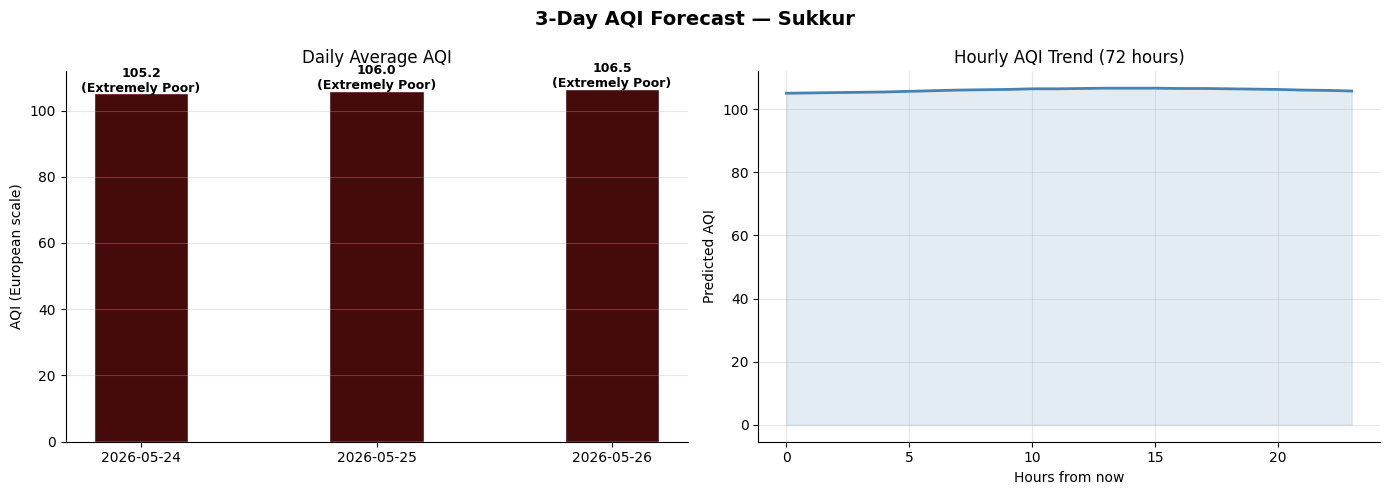

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"3-Day AQI Forecast — {CITY}", fontsize=14, fontweight="bold")

# Plot 1 — Daily forecast bars
bar_colors = [aqi_color(c) for c in daily["category"]]
bars = axes[0].bar(daily["date"], daily["predicted_aqi"],
                   color=bar_colors, edgecolor="white", width=0.4)
axes[0].set_title("Daily Average AQI")
axes[0].set_ylabel("AQI (European scale)")
for bar, (_, row) in zip(bars, daily.iterrows()):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{row['predicted_aqi']}\n({row['category']})",
        ha="center", fontsize=9, fontweight="bold"
    )
axes[0].grid(axis="y", alpha=0.3)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Plot 2 — Hourly trend
axes[1].plot(
    range(len(df_forecast)),
    df_forecast["predicted_aqi"],
    color="steelblue", lw=2
)
axes[1].fill_between(
    range(len(df_forecast)),
    df_forecast["predicted_aqi"],
    alpha=0.15, color="steelblue"
)
axes[1].set_title("Hourly AQI Trend (72 hours)")
axes[1].set_xlabel("Hours from now")
axes[1].set_ylabel("Predicted AQI")
axes[1].grid(alpha=0.3)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()